In [1]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

In [2]:
import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
#from torch_geometric.data import Batch
#from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from scripts.eval_utils import load_model

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

In [3]:
from hydra.experimental import compose
from hydra import initialize_config_dir

model_path = Path("/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/conf/")

with initialize_config_dir(str(model_path)):
    cfg = compose(config_name = 'default')
    datamodule = hydra.utils.instantiate(
        cfg.data.datamodule, _recursive_=False, scaler_path=None
    )
    datamodule.setup('test')
    test_loader = datamodule.test_dataloader()[0]

loader = test_loader

/home/gridsan/eriesel/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/train_20_any.csv
using existing graph file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/train_20_any.pt
no filter
using 271 rows given a train_fraction of 0.01
[Errno 2] No such file or directory: '/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/train_xrd_peak_intensities_dict.pt'
time taken: 2.8713786602020264


/data1/groups/Freedman_CDVAE/XRD_CDVAE_Repo/cdvae/common/data_utils.py:617: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)


constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/test_20_any.csv
using existing graph file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/test_20_any.pt
no filter
using 90 rows given a train_fraction of 0.01
[Errno 2] No such file or directory: '/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/test_xrd_peak_intensities_dict.pt'
time taken: 1.1017374992370605


In [4]:
list_of_idxs = []
list_of_batchs = []

for idx, batch in enumerate(loader):
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]

def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    disc_sim_xrd = batch_reserve[4]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch

batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch = new_dataloader_batch_processor(batch)

batch = batch.cuda()

batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []

The pattern will be accurate out to: 157.96318411669148
set mini_batch_size to be multiplicative factor of the batch size


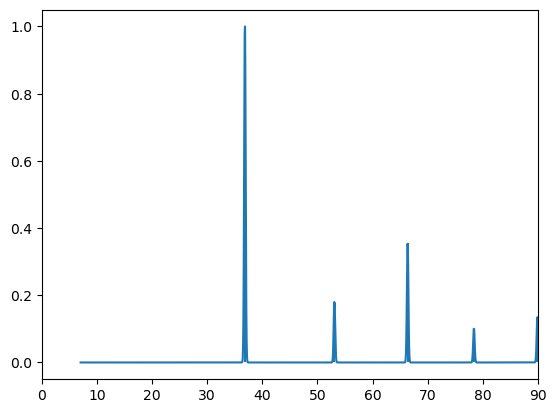

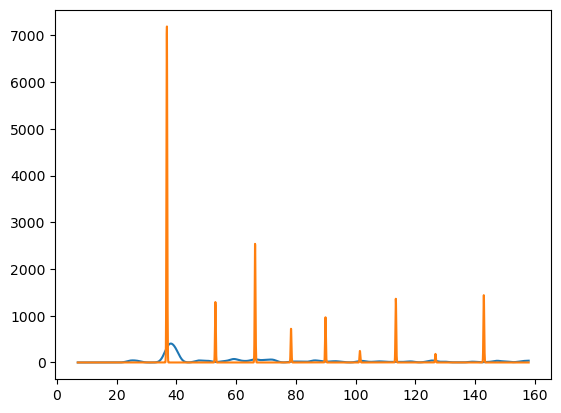

Step 1: Lengths - tensor([[3.3001, 3.6002, 3.1002]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-1.7231e-05, -1.3706e-04,  2.5932e-11],
        [ 4.0002e-01,  4.0014e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.2653903663158417


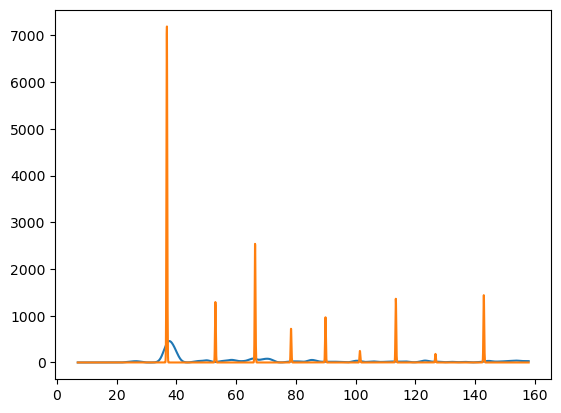

Step 201: Lengths - tensor([[3.3188, 3.6359, 3.1445]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.3701e-03, -1.9910e-02, -8.3230e-09],
        [ 4.0437e-01,  4.1991e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.31062042713165283


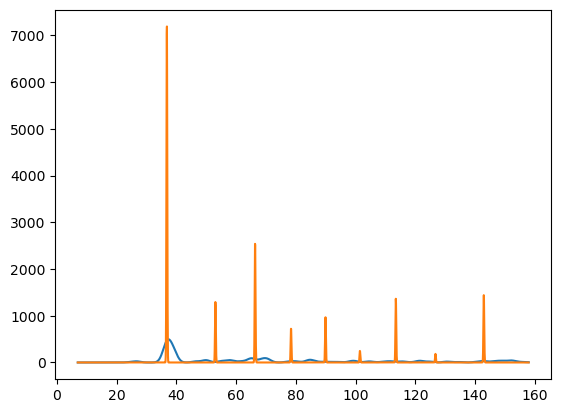

Step 401: Lengths - tensor([[3.3338, 3.6528, 3.1828]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.9427e-03, -2.9284e-02, -1.7124e-08],
        [ 4.0494e-01,  4.2928e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.33379775285720825


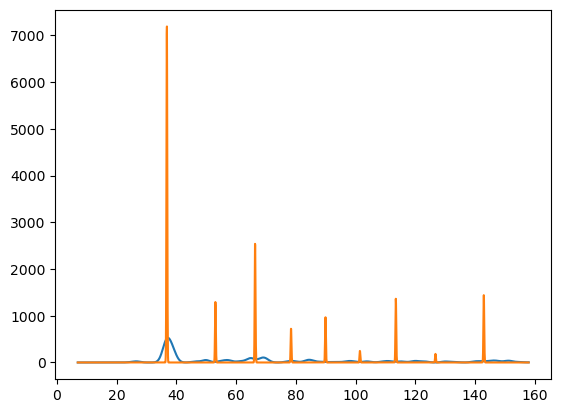

Step 601: Lengths - tensor([[3.3434, 3.6572, 3.2169]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-5.6546e-03, -3.3893e-02, -2.6097e-08],
        [ 4.0565e-01,  4.3389e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.34787383675575256


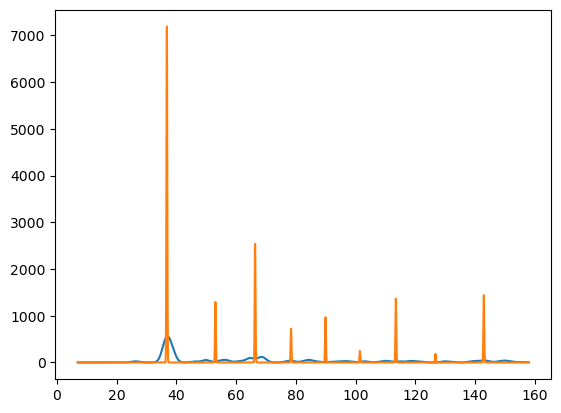

Step 801: Lengths - tensor([[3.3572, 3.6566, 3.2539]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-6.4624e-03, -3.6348e-02, -2.6651e-08],
        [ 4.0646e-01,  4.3635e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.36460721492767334


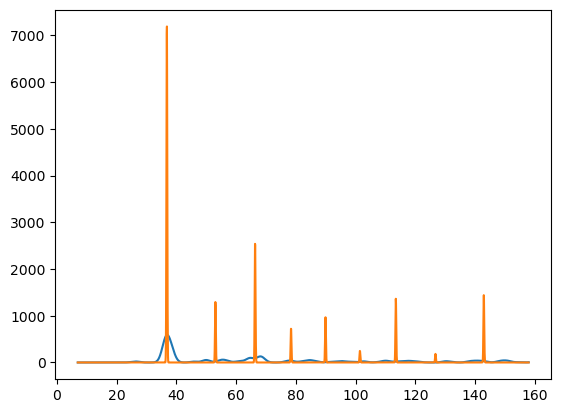

Step 1001: Lengths - tensor([[3.3667, 3.6494, 3.2781]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-9.2557e-03, -3.8212e-02, -1.2571e-08],
        [ 4.0926e-01,  4.3821e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.37313899397850037


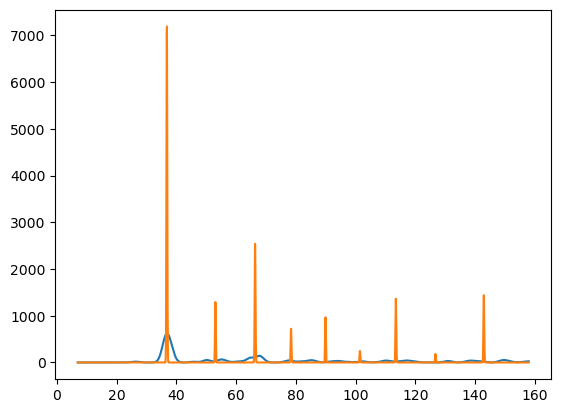

Step 1201: Lengths - tensor([[3.3784, 3.6353, 3.3006]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-1.3289e-02, -3.9422e-02, -8.5297e-09],
        [ 4.1329e-01,  4.3942e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.38300958275794983


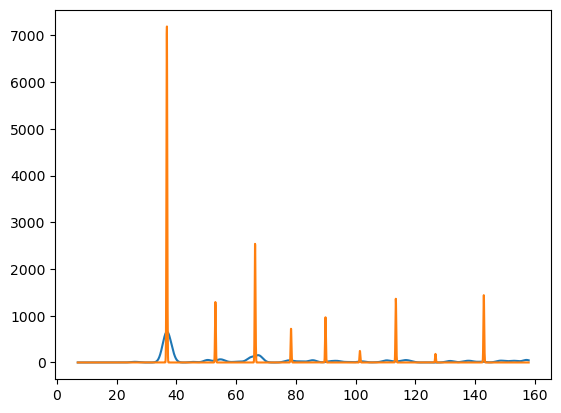

Step 1401: Lengths - tensor([[3.3966, 3.6156, 3.3176]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-1.8234e-02, -4.0314e-02, -6.7108e-09],
        [ 4.1823e-01,  4.4031e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.3947395086288452


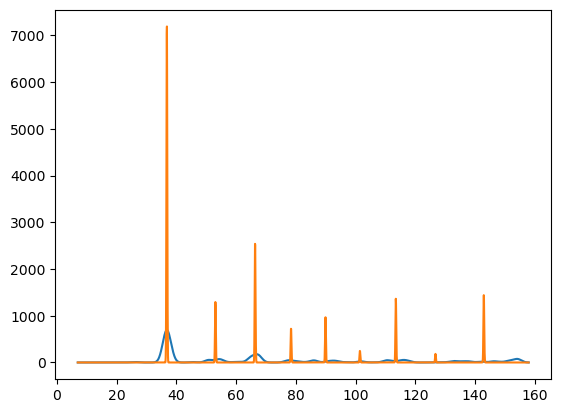

Step 1601: Lengths - tensor([[3.4140, 3.5951, 3.3375]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-2.3419e-02, -4.0885e-02, -7.5364e-09],
        [ 4.2342e-01,  4.4088e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.40780484676361084


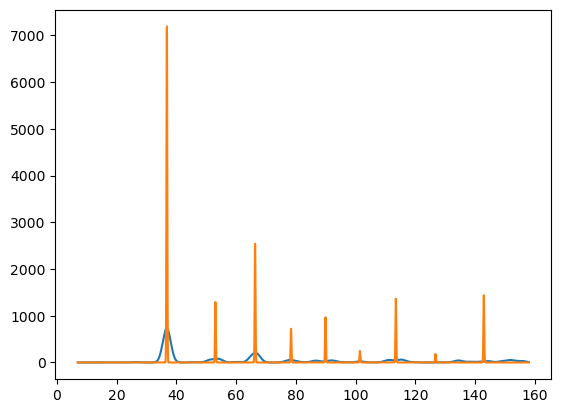

Step 1801: Lengths - tensor([[3.4308, 3.5688, 3.3598]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-2.8603e-02, -4.0973e-02, -8.8816e-09],
        [ 4.2860e-01,  4.4097e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.42454013228416443


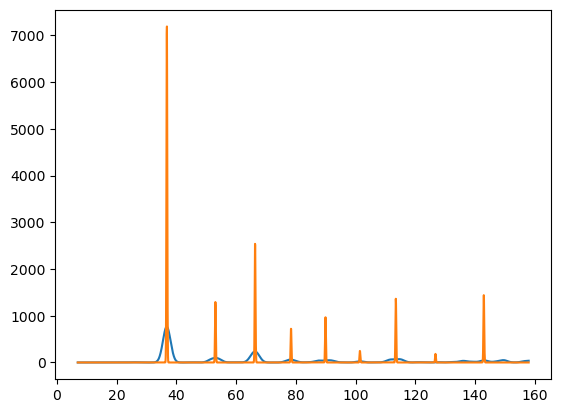

Step 2001: Lengths - tensor([[3.4438, 3.5409, 3.3772]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-3.4435e-02, -4.1023e-02, -7.7564e-09],
        [ 4.3444e-01,  4.4102e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.4396299421787262


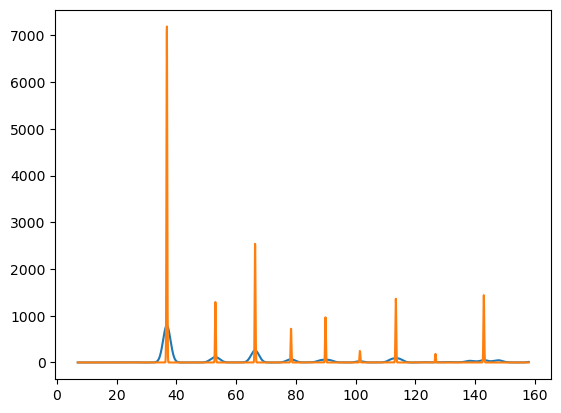

Step 2201: Lengths - tensor([[3.4475, 3.5155, 3.3933]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-3.8203e-02, -4.1229e-02, -5.7587e-09],
        [ 4.3820e-01,  4.4123e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.45108985900878906


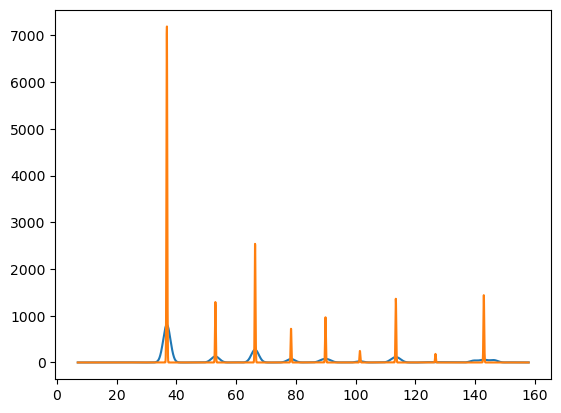

Step 2401: Lengths - tensor([[3.4489, 3.4956, 3.4087]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.0155e-02, -4.1287e-02, -3.9492e-09],
        [ 4.4016e-01,  4.4129e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.45956432819366455


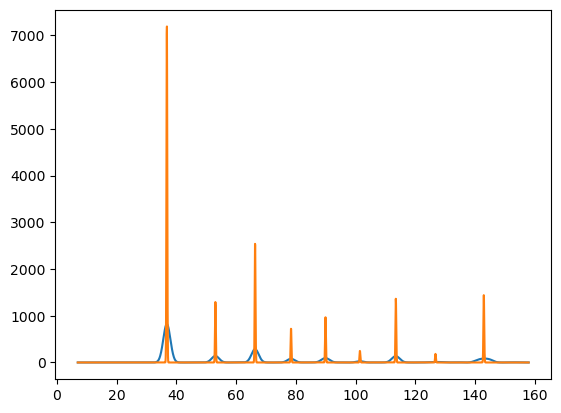

Step 2601: Lengths - tensor([[3.4496, 3.4783, 3.4242]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.1388e-02, -4.1249e-02, -1.7409e-09],
        [ 4.4139e-01,  4.4125e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.4671451449394226


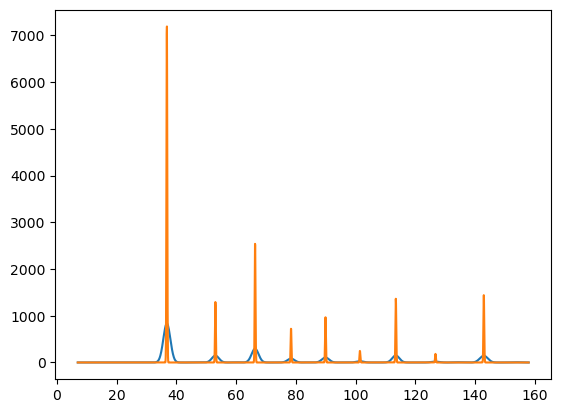

Step 2801: Lengths - tensor([[3.4494, 3.4613, 3.4405]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.2126e-02, -4.1386e-02, -4.8447e-10],
        [ 4.4213e-01,  4.4139e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.47501319646835327


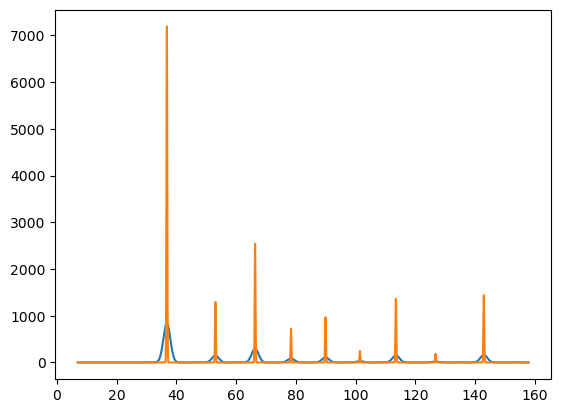

Step 3001: Lengths - tensor([[3.4497, 3.4528, 3.4476]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.2549e-02, -4.1759e-02,  1.4584e-10],
        [ 4.4255e-01,  4.4176e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.4787011742591858


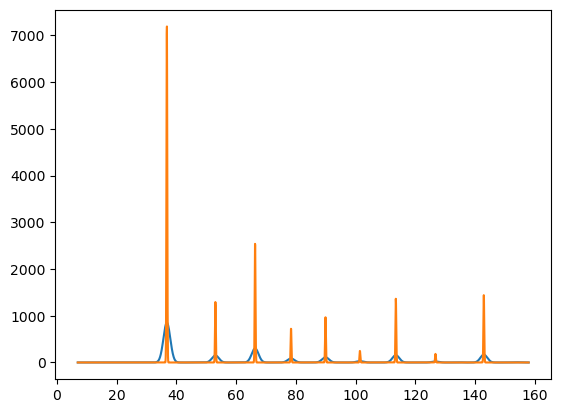

Step 3201: Lengths - tensor([[3.4499, 3.4507, 3.4494]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.2885e-02, -4.2126e-02,  5.1510e-10],
        [ 4.4289e-01,  4.4212e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.48113784193992615


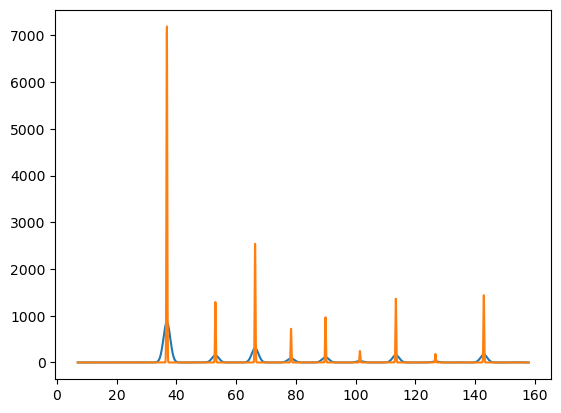

Step 3401: Lengths - tensor([[3.4500, 3.4501, 3.4499]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.3179e-02, -4.2451e-02,  7.7719e-10],
        [ 4.4318e-01,  4.4245e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.48349249362945557


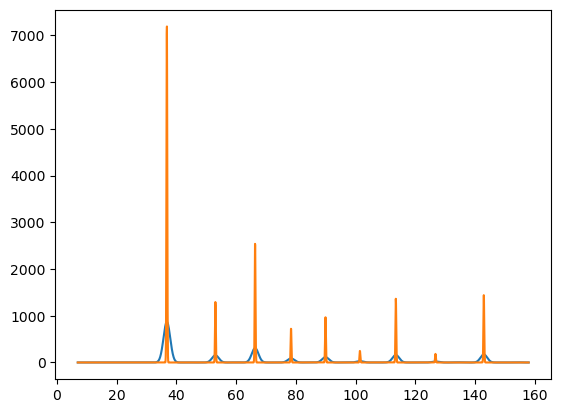

Step 3601: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.3441e-02, -4.2741e-02,  1.0149e-09],
        [ 4.4344e-01,  4.4274e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.48585134744644165


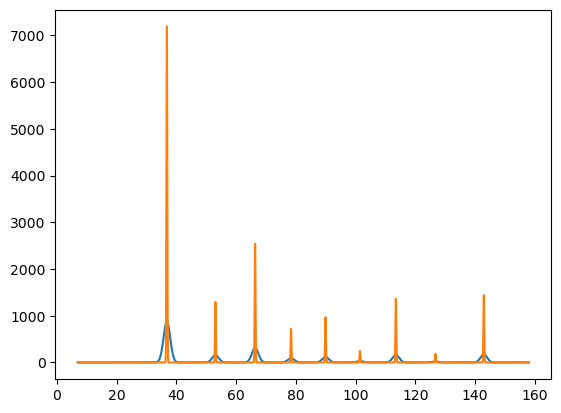

Step 3801: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.3676e-02, -4.3001e-02,  1.2275e-09],
        [ 4.4368e-01,  4.4300e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.48821941018104553


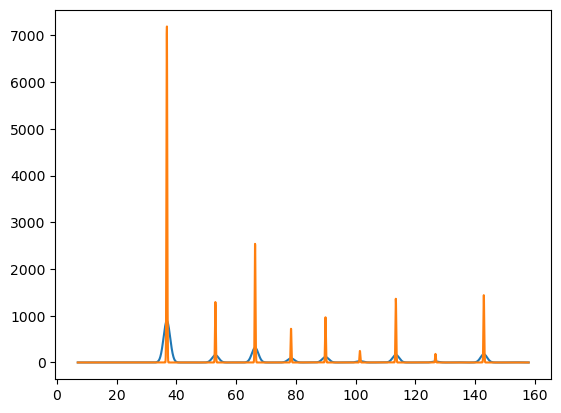

Step 4001: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.3888e-02, -4.3236e-02,  1.4181e-09],
        [ 4.4389e-01,  4.4324e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.4905972480773926


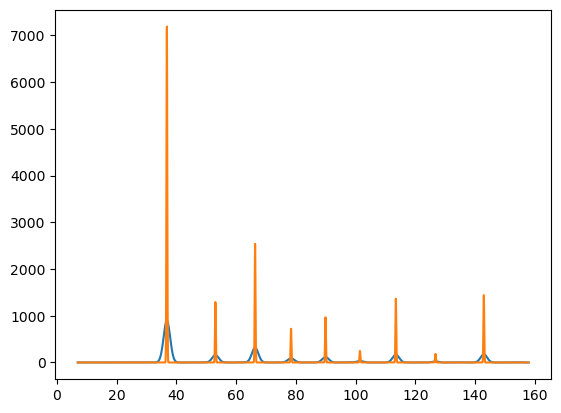

Step 4201: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.4082e-02, -4.3450e-02,  1.6060e-09],
        [ 4.4408e-01,  4.4345e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.49298471212387085


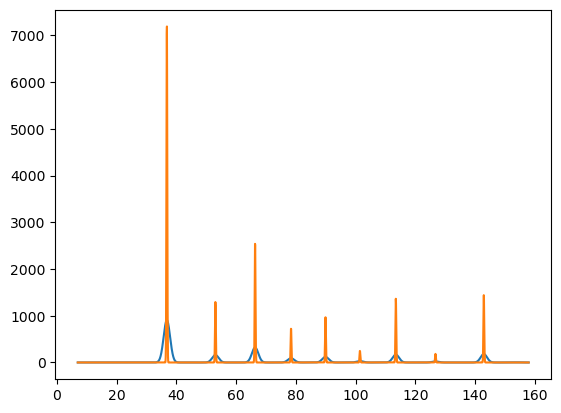

Step 4401: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.4258e-02, -4.3645e-02,  1.7818e-09],
        [ 4.4426e-01,  4.4364e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.495382159948349


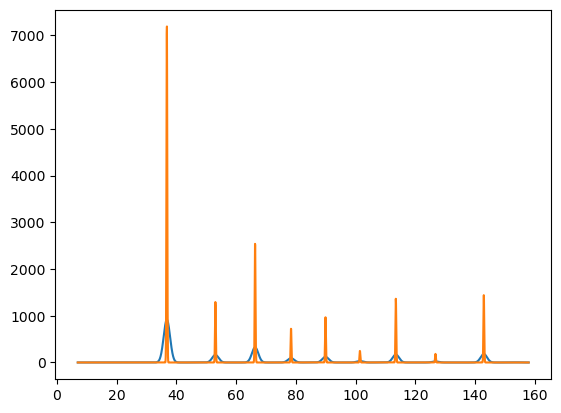

Step 4601: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.4421e-02, -4.3825e-02,  1.9384e-09],
        [ 4.4442e-01,  4.4382e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.49778950214385986


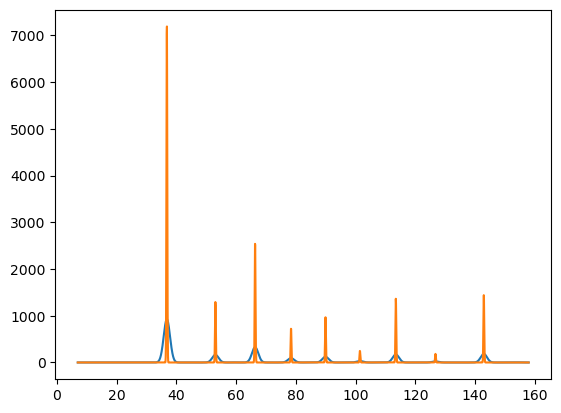

Step 4801: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.4571e-02, -4.3992e-02,  2.0931e-09],
        [ 4.4457e-01,  4.4399e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5002068281173706


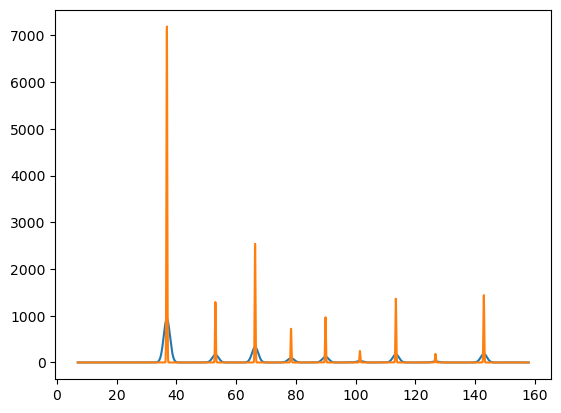

Step 5001: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.4710e-02, -4.4146e-02,  2.2439e-09],
        [ 4.4471e-01,  4.4414e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5026341676712036


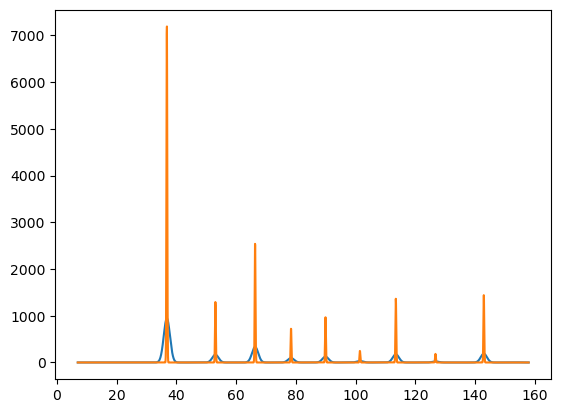

Step 5201: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.4840e-02, -4.4289e-02,  2.3868e-09],
        [ 4.4484e-01,  4.4429e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5050715208053589


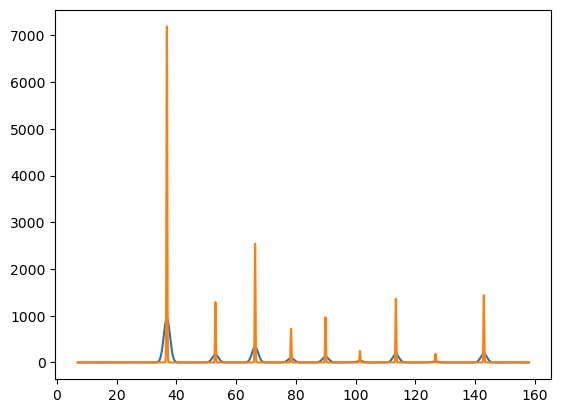

Step 5401: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.4961e-02, -4.4423e-02,  2.5166e-09],
        [ 4.4496e-01,  4.4442e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.507519006729126


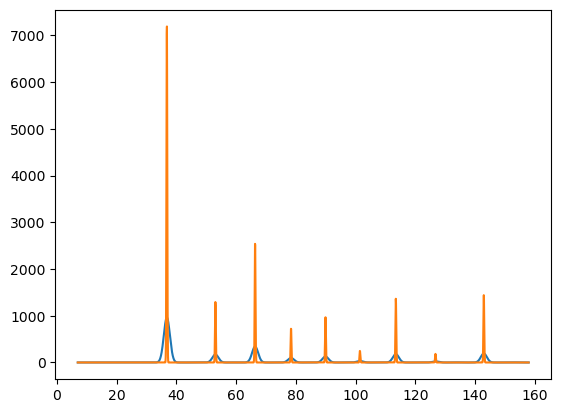

Step 5601: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5074e-02, -4.4549e-02,  2.6432e-09],
        [ 4.4507e-01,  4.4455e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5099763870239258


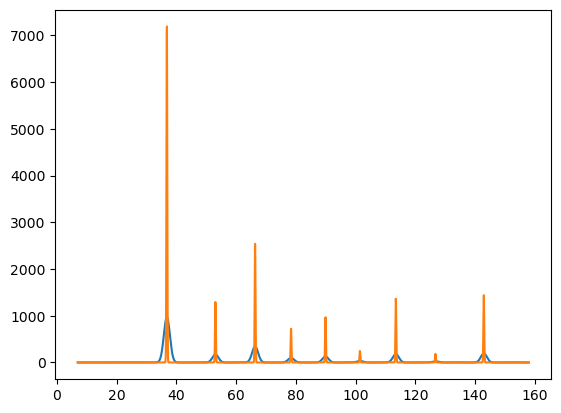

Step 5801: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5181e-02, -4.4666e-02,  2.7519e-09],
        [ 4.4518e-01,  4.4467e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5124440789222717


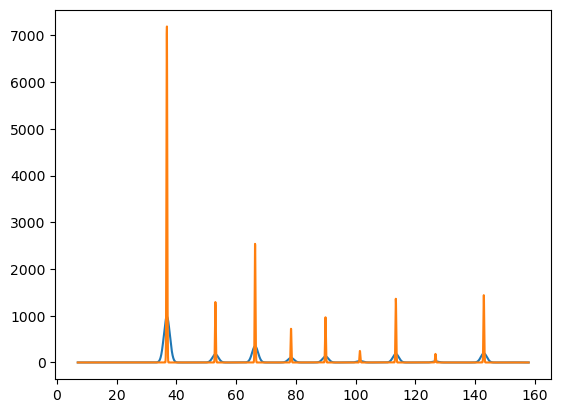

Step 6001: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5281e-02, -4.4778e-02,  2.8546e-09],
        [ 4.4528e-01,  4.4478e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5149217844009399


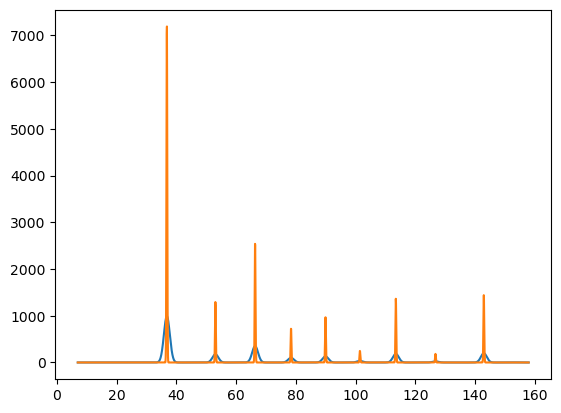

Step 6201: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5376e-02, -4.4882e-02,  2.9655e-09],
        [ 4.4538e-01,  4.4488e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5174096822738647


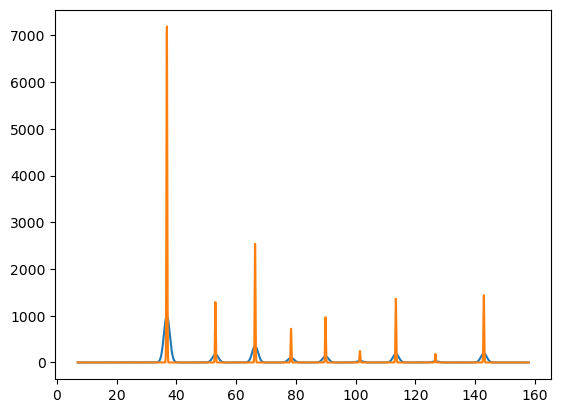

Step 6401: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5465e-02, -4.4982e-02,  3.0595e-09],
        [ 4.4547e-01,  4.4498e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.519907534122467


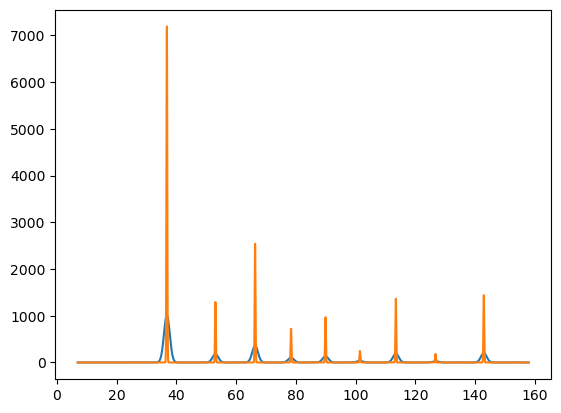

Step 6601: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5550e-02, -4.5076e-02,  3.1470e-09],
        [ 4.4555e-01,  4.4508e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5224155783653259


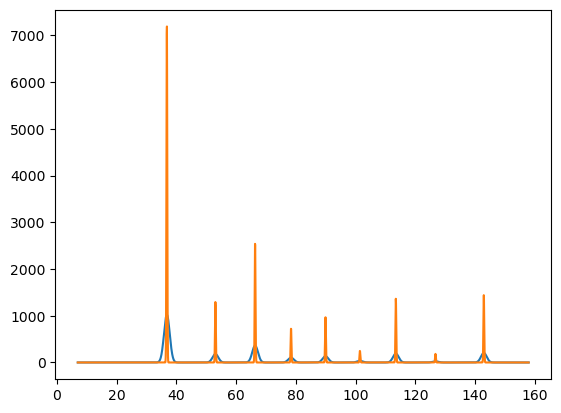

Step 6801: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5631e-02, -4.5165e-02,  3.2364e-09],
        [ 4.4563e-01,  4.4516e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5249337553977966


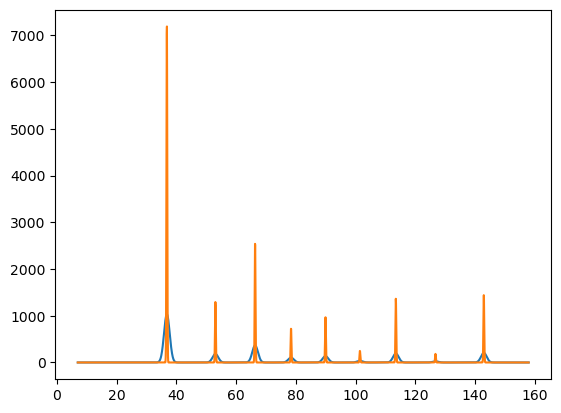

Step 7001: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5708e-02, -4.5250e-02,  3.3310e-09],
        [ 4.4571e-01,  4.4525e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5274620652198792


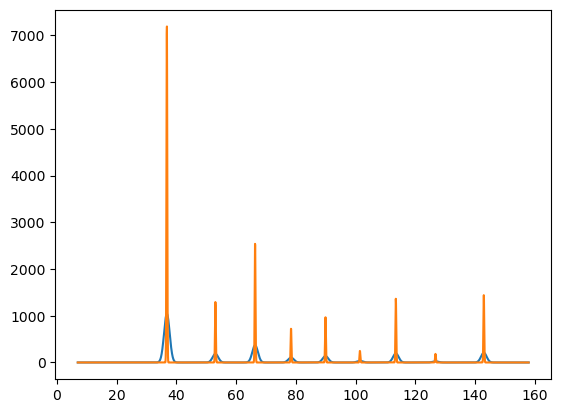

Step 7201: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5781e-02, -4.5331e-02,  3.4204e-09],
        [ 4.4578e-01,  4.4533e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5300004482269287


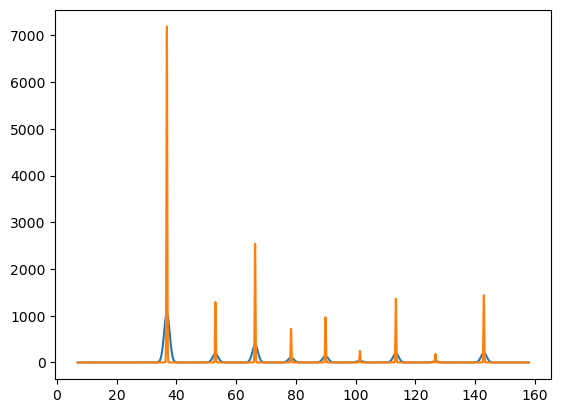

Step 7401: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5851e-02, -4.5409e-02,  3.5029e-09],
        [ 4.4585e-01,  4.4541e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5325487852096558


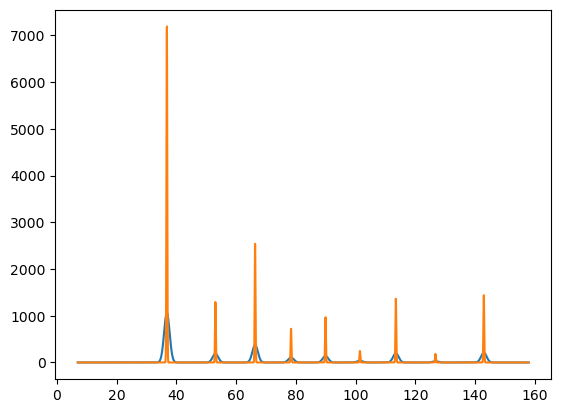

Step 7601: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5918e-02, -4.5483e-02,  3.5858e-09],
        [ 4.4592e-01,  4.4548e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5351073145866394


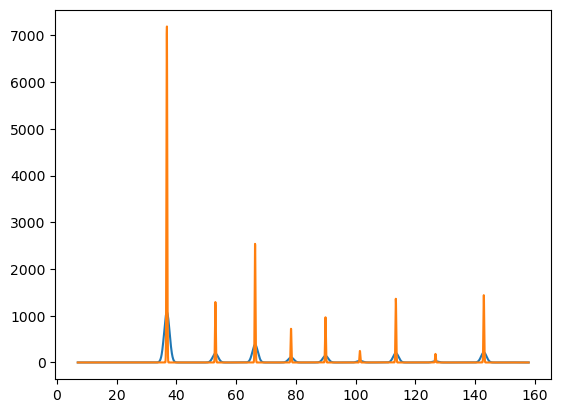

Step 7801: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.5982e-02, -4.5554e-02,  3.6656e-09],
        [ 4.4598e-01,  4.4555e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5376759767532349


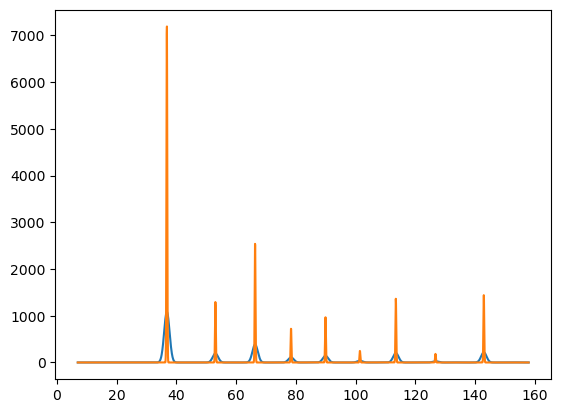

Step 8001: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6044e-02, -4.5622e-02,  3.7410e-09],
        [ 4.4604e-01,  4.4562e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5402545928955078


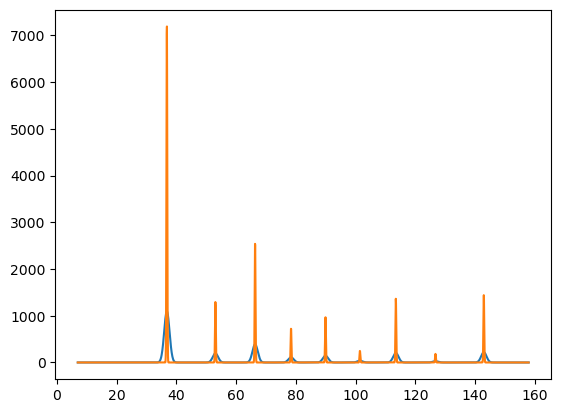

Step 8201: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6103e-02, -4.5687e-02,  3.8054e-09],
        [ 4.4610e-01,  4.4569e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5428433418273926


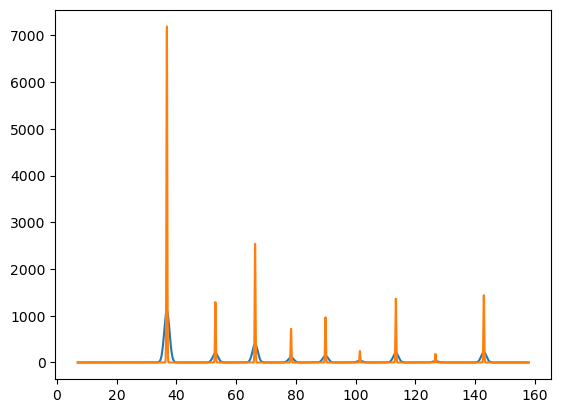

Step 8401: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6159e-02, -4.5750e-02,  3.8724e-09],
        [ 4.4616e-01,  4.4575e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5454419851303101


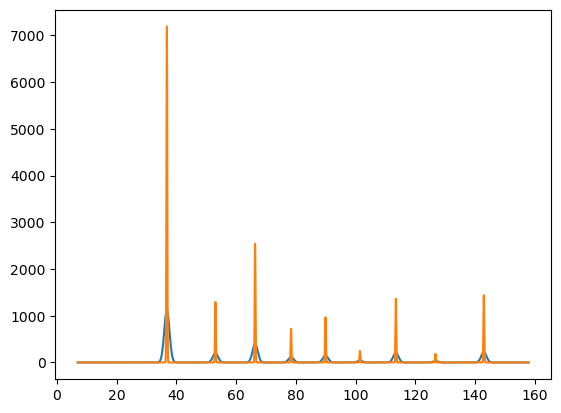

Step 8601: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6214e-02, -4.5810e-02,  3.9408e-09],
        [ 4.4621e-01,  4.4581e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5480507612228394


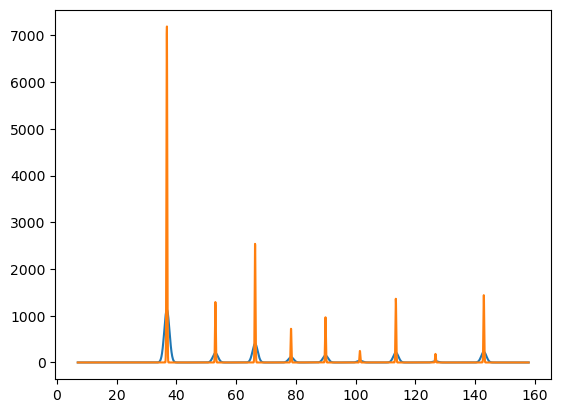

Step 8801: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6267e-02, -4.5868e-02,  4.0081e-09],
        [ 4.4627e-01,  4.4587e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5506693720817566


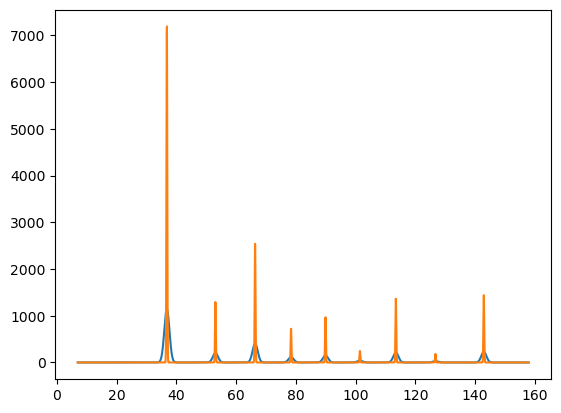

Step 9001: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6317e-02, -4.5924e-02,  4.0673e-09],
        [ 4.4632e-01,  4.4592e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5532981157302856


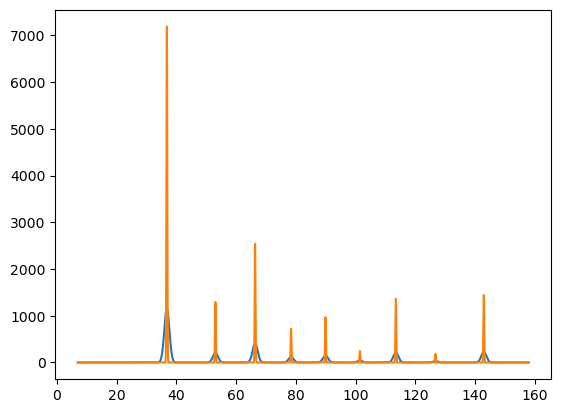

Step 9201: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6366e-02, -4.5979e-02,  4.1196e-09],
        [ 4.4637e-01,  4.4598e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5559366941452026


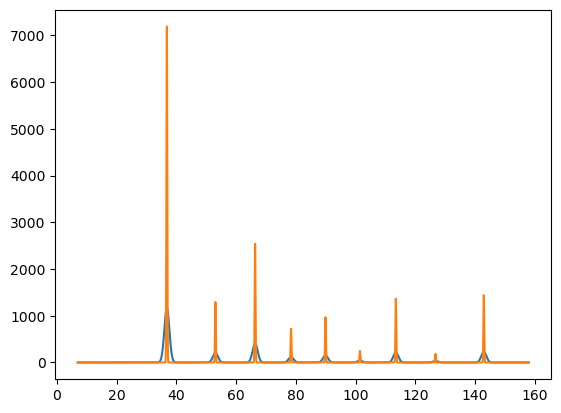

Step 9401: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6413e-02, -4.6031e-02,  4.1734e-09],
        [ 4.4641e-01,  4.4603e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5585852265357971


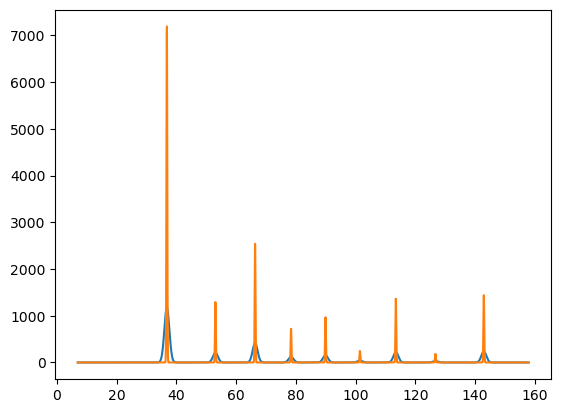

Step 9601: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6459e-02, -4.6081e-02,  4.2278e-09],
        [ 4.4646e-01,  4.4608e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5612435936927795


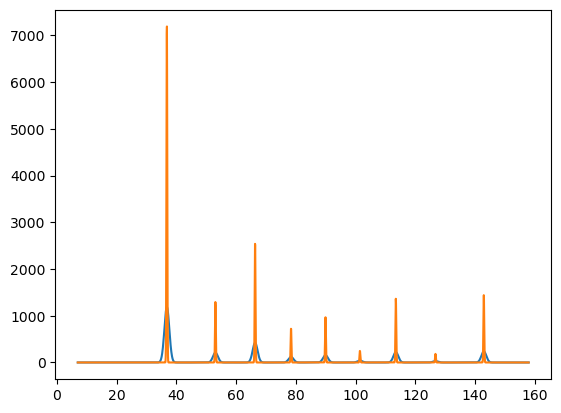

Step 9801: Lengths - tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[-4.6503e-02, -4.6130e-02,  4.2875e-09],
        [ 4.4650e-01,  4.4613e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.5639119148254395
{'angles': tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), 'lengths': tensor([[3.4500, 3.4500, 3.4500]], device='cuda:0', requires_grad=True), 'frac_coords': tensor([[-4.6546e-02, -4.6177e-02,  4.3444e-09],
        [ 4.4654e-01,  4.4618e-01,  5.0000e-01]], device='cuda:0',
       requires_grad=True), 'num_atoms': tensor([2], device='cuda:0'), 'atom_types': tensor([3, 3], device='cuda:0')}


"\npattern[1][0][3].backward()\n#print(pattern[:,0,:])\n#print(batch['angles'][0])\nprint(batch['angles'].grad)\n#print(batch['frac_coords'][0])\nprint(batch['frac_coords'].grad)\n#scan = DC.bin_pattern_theta(pattern)\n#print(scan)\n#plt.plot(scan)"

In [1]:
#NOTE THE INTENSITIES WILL LOOK WRONG IF THE DOMAIN IS SET TOO WIDE WITH TOO FEW STEPS

import diffraction as dc
from math import pi
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator


batch = {
    'angles': torch.tensor([[90.0,90.0,90.0]], requires_grad = False).cuda(),
    'lengths': torch.tensor([[3.45, 3.45, 3.45]], requires_grad = False).cuda(),
    'frac_coords': torch.tensor([[0,0,0],[0.5, 0.5, 0.5]], requires_grad = False).cuda(),
    'num_atoms': torch.tensor([2]).cuda(),
    'atom_types': torch.tensor([3,3]).cuda()
}


q_max = 8
wavelength = 1.54184
max_two_theta = 90
print("The pattern will be accurate out to:", np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi)


#DC = dc.diffraction_calculator(q_max=10, q_step=0.1, q_width=0.1, wavelength=1.0, device='cpu')
DC = dc.diffraction_pattern(q_max= q_max, wavelength= wavelength)


mini_batch_size = 8
if batch['angles'].size()[0] % mini_batch_size != 0:
    print("set mini_batch_size to be multiplicative factor of the batch size")



pattern = DC.diffraction_calc(batch, indices = [0,8])

pymat_pattern = DC.pymatgen_pattern(pattern[:,0,:])[2:]
pymat_pattern[:,1] = pymat_pattern[:,1]/ torch.max(pymat_pattern[:,1])

scan, domain = DC.bin_pattern_theta(pattern, num_steps = 2560)


xrd_calculator = XRDCalculator(wavelength=wavelength)#, symprec=0.1)

structure = Structure(
    lattice=Lattice.from_parameters(
        *(batch['lengths'][0].tolist() + batch['angles'][0].tolist())),
        species=batch['atom_types'].tolist(), coords=batch['frac_coords'].tolist(), coords_are_cartesian=False)

pymatgen_pattern = xrd_calculator.get_pattern(structure)



plt.plot(domain.cpu().detach().numpy(), scan[0].cpu().detach().numpy() / torch.max(scan[0]).cpu().detach().numpy())
plt.vlines(pymatgen_pattern.x, np.zeros(len(pymatgen_pattern.x)), pymatgen_pattern.y / np.max(pymatgen_pattern.y))
plt.xlim(0,max_two_theta)
plt.show()
plt.close()



batch = {
    'angles': torch.tensor([[90.0,90.0,90.0]], requires_grad = True).cuda(),
    'lengths': torch.tensor([[3.3, 3.6, 3.1]], requires_grad = True).cuda(),
    'frac_coords': torch.tensor([[0,0,0],[0.4, 0.4, 0.5]], requires_grad = True).cuda(),
    'num_atoms': torch.tensor([2]).cuda(),
    'atom_types': torch.tensor([3,3]).cuda()
}

batch['lengths'] = batch['lengths'].clone().detach().requires_grad_(True)
batch['angles'] = batch['angles'].clone().detach().requires_grad_(True)
batch['frac_coords'] = batch['frac_coords'].clone().detach().requires_grad_(True)



print(DC.snap_structure(scan[0], batch, iterations = 10000, learning_rate = 0.0005, U = 0, V = 0, W = 10, sharpen_rate = 0.0001, plot_progress = True, plot_freq = 200))





"""
max_r = self.q_max / (2 * pi)
max_recip_length = q_max /2pi
two theta = 360 / pi * arcsin(wavelength * recip_length / 2)"""


"""
pattern[1][0][3].backward()
#print(pattern[:,0,:])
#print(batch['angles'][0])
print(batch['angles'].grad)
#print(batch['frac_coords'][0])
print(batch['frac_coords'].grad)
#scan = DC.bin_pattern_theta(pattern)
#print(scan)
#plt.plot(scan)"""